# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 2 — Entrenamiento de modelos (evaluación en TRAIN y VALIDACIÓN)
### Diplomatura IA - UP
### Alumno: Gonzalez Marta Elizabeth
### Mes: Julio26

1. Se agrega un **split de 3 partes**: train / validación / test (70/15/15), en vez de solo train/test. El **test queda completamente reservado** para el Notebook 3 (evaluación final única) — acá solo se usa train y validación.
2. Cada modelo se evalúa con `classification_report` **tanto en train como en validación**, para poder detectar overfitting (si el desempeño en train es mucho mejor que en validación, el modelo memorizó en vez de generalizar).
3. La **selección del mejor modelo** (comparando en validación) se hace en el Notebook 3, no acá — este notebook se limita a entrenar y reportar train/validación de cada candidato.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.sparse import hstack, csr_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7,5)

mega = pd.read_csv('../data/processed/mega_clean.csv')
print('Megaset:', mega.shape)
print(mega['target'].value_counts())


Megaset: (1592728, 30)
target
0    796693
4    795896
2       139
Name: count, dtype: int64


## 1. Split en 3 partes: Train / Validación / Test (70/15/15)

- **Train (70%):** para ajustar los modelos.
- **Validación (15%):** para comparar modelos entre sí y elegir el mejor (Notebook 3) — nunca se usa para entrenar.
- **Test (15%):** se reserva completamente hasta el Notebook 3, donde se usa **una sola vez** para la evaluación final del modelo ya elegido. No tocarlo acá evita el sesgo de "espiar" el test durante el desarrollo.

División en dos pasos (primero separamos test, después separamos validación del resto), ambos estratificados por `target` para que la clase neutral (minoría extrema) quede representada en las 3 partes.

In [6]:
train_val, test = train_test_split(mega, test_size=0.15, stratify=mega['target'], random_state=42)
train, val = train_test_split(train_val, test_size=0.15/0.85, stratify=train_val['target'], random_state=42)

train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)

print(f'Train:      {len(train):>6} filas | {train["target"].value_counts().to_dict()}')
print(f'Validación: {len(val):>6} filas | {val["target"].value_counts().to_dict()}')
print(f'Test:       {len(test):>6} filas | {test["target"].value_counts().to_dict()}')

# Guardamos los 3 splits para que los notebooks 3 y 4 usen exactamente los mismos (no re-splitear)
train.to_csv('../data/processed/split_train.csv', index=False)
val.to_csv('../data/processed/split_val.csv', index=False)
test.to_csv('../data/processed/split_test.csv', index=False)
print('\nGuardado: ../data/processed/split_train.csv, ../data/processed/split_val.csv, ../data/processed/split_test.csv')


Train:      1114908 filas | {0: 557685, 4: 557126, 2: 97}
Validación: 238910 filas | {0: 119504, 4: 119385, 2: 21}
Test:       238910 filas | {0: 119504, 4: 119385, 2: 21}

Guardado: ../data/processed/split_train.csv, ../data/processed/split_val.csv, ../data/processed/split_test.csv


## 2. Vectorización TF-IDF (ajustada solo con train)

### Elección de `max_features`
Con un dataset de 1.6M+ documentos, el vocabulario real (después de `min_df=5`, que ya filtra términos raros) es mucho más grande que en la muestra de prueba — conviene medirlo antes de fijar un tope arbitrario, para no descartar de más vocabulario potencialmente útil (bigramas específicos de sentimiento, por ejemplo).

In [7]:
# Chequeo del vocabulario real, sin tope, para decidir max_features con criterio
tfidf_check = TfidfVectorizer(ngram_range=(1,2), min_df=5)
tfidf_check.fit(train['clean_text'])
print('Vocabulario real (sin max_features):', len(tfidf_check.vocabulary_))


Vocabulario real (sin max_features): 209457


Con >200.000 términos reales en el megaset completo, un tope de `max_features=20000` (razonable para la muestra chica de prueba) descartaría demasiado vocabulario específico. Con >1.6M documentos de soporte, el riesgo de overfitting por usar más vocabulario es bajo — **se usa el vocabulario completo (`max_features=None`)**, dejando que `min_df=5` sea el único filtro. Como la matriz TF-IDF es dispersa (*sparse*), el costo en memoria depende sobre todo de cuántos términos no-cero tiene cada documento (que no cambia con el tamaño del vocabulario), así que no usar tope no implica un salto serio de memoria — el único costo real es algo más de tiempo de entrenamiento, marginal frente al resto del pipeline con 1.6M+ documentos.

In [8]:
tfidf = TfidfVectorizer(max_features=None, ngram_range=(1,2), min_df=5)
Xtr = tfidf.fit_transform(train['clean_text'])
Xval = tfidf.transform(val['clean_text'])

ytr = train['target']
yval = val['target']

print('Vocabulario usado:', len(tfidf.vocabulary_))
print('Shape train vectorizado:', Xtr.shape)


Vocabulario usado: 209457
Shape train vectorizado: (1114908, 209457)


## 3. Features de ingeniería (del Notebook 1), escaladas con train

In [9]:
FEATURE_COLS = [
    'n_chars', 'n_words', 'avg_word_len', 'n_exclamation', 'n_question',
    'n_uppercase_words', 'n_elongated', 'n_pos_emoticons', 'n_neg_emoticons',
    'n_mentions_count', 'n_hashtags_count', 'n_lex_pos', 'n_lex_neg', 'lex_pos_neg_diff',
]

scaler = StandardScaler()
Xtr_feat = scaler.fit_transform(train[FEATURE_COLS])
Xval_feat = scaler.transform(val[FEATURE_COLS])

Xtr_combinado = hstack([Xtr, csr_matrix(Xtr_feat)])
Xval_combinado = hstack([Xval, csr_matrix(Xval_feat)])


## 4. Función auxiliar: reporte en TRAIN y VALIDACIÓN

Para no repetir código, una función que entrena, predice sobre ambos conjuntos, y muestra los dos `classification_report` uno al lado del otro — así se puede comparar de un vistazo si el modelo generaliza bien o está sobreajustando.

In [10]:
def evaluar_train_val(modelo, Xtr_, ytr_, Xval_, yval_, nombre):
    pred_tr = modelo.predict(Xtr_)
    pred_val = modelo.predict(Xval_)

    f1_tr = f1_score(ytr_, pred_tr, average='macro')
    f1_val = f1_score(yval_, pred_val, average='macro')

    print(f'=== {nombre} — TRAIN ===')
    print(classification_report(ytr_, pred_tr, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))
    print(f'=== {nombre} — VALIDACIÓN ===')
    print(classification_report(yval_, pred_val, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))

    gap = f1_tr - f1_val
    print(f'F1 macro train: {f1_tr:.4f} | F1 macro validación: {f1_val:.4f} | Gap (overfitting): {gap:.4f}')
    return {'modelo': nombre, 'f1_train': f1_tr, 'f1_val': f1_val, 'gap': gap, 'pred_val': pred_val}


## 5. Modelo candidato 1 — Naive Bayes (balanceado, solo TF-IDF)

In [11]:
sample_weights = compute_sample_weight(class_weight='balanced', y=ytr)

nb_model = MultinomialNB()
nb_model.fit(Xtr, ytr, sample_weight=sample_weights)

resumen_nb = evaluar_train_val(nb_model, Xtr, ytr, Xval, yval, 'Naive Bayes')


=== Naive Bayes — TRAIN ===
              precision    recall  f1-score   support

    Negativo       0.82      0.82      0.82    557685
     Neutral       0.02      1.00      0.04        97
    Positivo       0.82      0.81      0.81    557126

    accuracy                           0.81   1114908
   macro avg       0.55      0.88      0.56   1114908
weighted avg       0.82      0.81      0.82   1114908

=== Naive Bayes — VALIDACIÓN ===
              precision    recall  f1-score   support

    Negativo       0.78      0.79      0.79    119504
     Neutral       0.01      0.38      0.01        21
    Positivo       0.79      0.78      0.78    119385

    accuracy                           0.78    238910
   macro avg       0.53      0.65      0.53    238910
weighted avg       0.79      0.78      0.78    238910

F1 macro train: 0.5557 | F1 macro validación: 0.5276 | Gap (overfitting): 0.0281


## 6. Modelo candidato 2 — Regresión Logística (balanceada, solo TF-IDF)

In [12]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(Xtr, ytr)

resumen_lr = evaluar_train_val(lr_model, Xtr, ytr, Xval, yval, 'Regresión Logística (TF-IDF)')


=== Regresión Logística (TF-IDF) — TRAIN ===
              precision    recall  f1-score   support

    Negativo       0.84      0.82      0.83    557685
     Neutral       0.24      1.00      0.39        97
    Positivo       0.82      0.84      0.83    557126

    accuracy                           0.83   1114908
   macro avg       0.64      0.89      0.68   1114908
weighted avg       0.83      0.83      0.83   1114908

=== Regresión Logística (TF-IDF) — VALIDACIÓN ===
              precision    recall  f1-score   support

    Negativo       0.81      0.79      0.80    119504
     Neutral       0.07      0.29      0.12        21
    Positivo       0.80      0.81      0.81    119385

    accuracy                           0.80    238910
   macro avg       0.56      0.63      0.57    238910
weighted avg       0.80      0.80      0.80    238910

F1 macro train: 0.6839 | F1 macro validación: 0.5740 | Gap (overfitting): 0.1099


## 7. Modelo candidato 3 — Regresión Logística + Feature Engineering

In [13]:
lr_fe_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_fe_model.fit(Xtr_combinado, ytr)

resumen_lr_fe = evaluar_train_val(lr_fe_model, Xtr_combinado, ytr, Xval_combinado, yval, 'Regresión Logística + FE')


=== Regresión Logística + FE — TRAIN ===
              precision    recall  f1-score   support

    Negativo       0.84      0.82      0.83    557685
     Neutral       0.27      1.00      0.43        97
    Positivo       0.83      0.85      0.84    557126

    accuracy                           0.83   1114908
   macro avg       0.65      0.89      0.70   1114908
weighted avg       0.84      0.83      0.83   1114908

=== Regresión Logística + FE — VALIDACIÓN ===
              precision    recall  f1-score   support

    Negativo       0.81      0.79      0.80    119504
     Neutral       0.08      0.29      0.13        21
    Positivo       0.80      0.82      0.81    119385

    accuracy                           0.81    238910
   macro avg       0.57      0.63      0.58    238910
weighted avg       0.81      0.81      0.81    238910

F1 macro train: 0.6990 | F1 macro validación: 0.5805 | Gap (overfitting): 0.1185


## 8. Comparación rápida: ¿algún modelo sobreajusta?

El `gap` (F1 train − F1 validación) es la señal de overfitting: cuanto más grande, más "memorizó" el modelo el train en vez de aprender patrones generalizables.

                      modelo  f1_train   f1_val      gap
                 Naive Bayes  0.555713 0.527603 0.028110
Regresión Logística (TF-IDF)  0.683945 0.574019 0.109925
    Regresión Logística + FE  0.699000 0.580542 0.118458


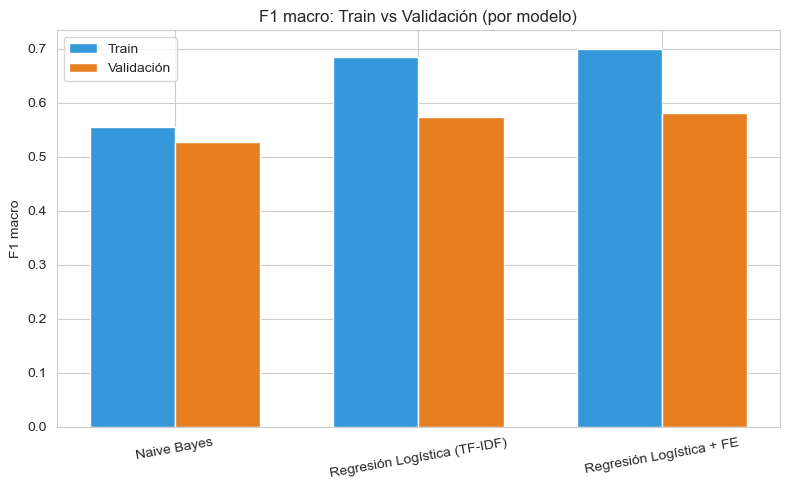

In [14]:
tabla_overfitting = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'pred_val'}
    for r in [resumen_nb, resumen_lr, resumen_lr_fe]
])
print(tabla_overfitting.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(tabla_overfitting))
width = 0.35
ax.bar(x - width/2, tabla_overfitting['f1_train'], width, label='Train', color='#3498db')
ax.bar(x + width/2, tabla_overfitting['f1_val'], width, label='Validación', color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels(tabla_overfitting['modelo'], rotation=10)
ax.set_ylabel('F1 macro')
ax.set_title('F1 macro: Train vs Validación (por modelo)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs_nb2_train_vs_val.png', dpi=110, bbox_inches='tight')
plt.show()


**Observación:** es esperable que el F1 en train sea algo más alto que en validación en los tres modelos (los modelos siempre ven mejor lo que ya usaron para aprender) — lo importante es que el `gap` no sea enorme. Un gap grande indicaría que el modelo está sobreajustando al train y no va a generalizar bien; un gap chico es señal de que el modelo generaliza razonablemente. La elección del mejor modelo (Notebook 3) usa el F1 de **validación**, no el de train, justamente para no premiar a un modelo que solo memorizó.

## 9. Guardado de modelos y artefactos para el Notebook 3

In [15]:
import pickle

with open('../data/processed/tfidf_vectorizer_mega.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('../data/processed/scaler_features.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('../data/processed/nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
with open('../data/processed/lr_model_mega.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('../data/processed/lr_fe_model.pkl', 'wb') as f:
    pickle.dump(lr_fe_model, f)

print('Guardado: vectorizador, scaler, y los 3 modelos entrenados (NB, LR, LR+FE)')


Guardado: vectorizador, scaler, y los 3 modelos entrenados (NB, LR, LR+FE)


## 10. Resumen de decisiones — Notebook 2 

1. Se agregó un **split de 3 partes** (train/validación/test, 70/15/15 estratificado) — el test se guarda pero no se toca en este notebook.
2. Cada uno de los 3 modelos candidatos (Naive Bayes, Regresión Logística, Regresión Logística + Feature Engineering) se evalúa con `classification_report` **en train y en validación**, permitiendo detectar overfitting mirando el gap entre ambos.
3. Se guardan los 3 modelos entrenados, el vectorizador TF-IDF y el scaler de features — la **selección del mejor modelo** (comparando en validación) y la **evaluación final única en test** se hacen en el Notebook 3, para mantener separadas las etapas de "entrenar" y "elegir/evaluar".

**Continúa en `03_validacion_seleccion_modelo.ipynb`.**